# Olist data EDA

In [52]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import numpy as np
from plots import Plotter
from scipy.stats import mannwhitneyu, spearmanr, chi2_contingency
import sys
sys.path.append('..')

from src.features.haversine import haversine_distance

### DB connection

In [2]:
conn = duckdb.connect('../data/olist.duckdb')

df = conn.execute("SELECT * FROM analytical_base_table").fetchdf()
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng
0,2ec63bd84c4e873ee8bf8786f4942673,9b9ceeaad1b990f974d6fc842ad6569d,sao paulo,SP,2017-07-20 18:57:41,6,5,NaN,179.90,10.00,200,informatica_acessorios,SP,189.90,8,-23.618858,-46.728590,-23.224503,-45.887843
1,f25ddb6cd62d720a5d91fff80467930a,c7fa006dc114bb846a9467bc0199f346,manaus,AM,2018-01-13 13:19:46,6,3,A entrega foi dividida em duas. Não houve comu...,388.00,32.13,10750,bebes,SP,420.13,8,-3.106169,-60.061105,-22.757883,-47.417055
2,966d505c98ea667c11343331a5d67722,622ab02b1f004f1b9a11fee1634bd1c7,saudades,SC,2017-08-03 19:48:22,22,5,NaN,39.90,16.79,150,telefonia,MG,56.69,1,-26.925368,-53.004313,-18.913248,-48.278212
3,031cf625cad56f5761e51c2675f0c0ae,eecd7a13b230f1cceae63dcefe543249,sao luis,MA,2017-03-18 06:52:28,17,3,NaN,56.99,24.89,300,perfumaria,SP,81.88,6,-2.570936,-44.206468,-23.659364,-46.523183
4,08d7ec7381dc51d41a0e4d86314b7a98,d401b738861201747e01d84768cd876d,rio de janeiro,RJ,2017-01-10 17:18:09,16,1,NaN,699.17,20.59,600,relogios_presentes,PR,719.76,10,-22.984160,-43.224955,-24.702966,-54.237448


### Haversine Distancing

In [3]:
df['geo_distance_km'] = haversine_distance(df['customer_lat'], df['customer_lng'], df['seller_lat'], df['seller_lng'])

In [4]:
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng,geo_distance_km
0,2ec63bd84c4e873ee8bf8786f4942673,9b9ceeaad1b990f974d6fc842ad6569d,sao paulo,SP,2017-07-20 18:57:41,6,5,NaN,179.90,10.00,200,informatica_acessorios,SP,189.90,8,-23.618858,-46.728590,-23.224503,-45.887843,96.341372
1,f25ddb6cd62d720a5d91fff80467930a,c7fa006dc114bb846a9467bc0199f346,manaus,AM,2018-01-13 13:19:46,6,3,A entrega foi dividida em duas. Não houve comu...,388.00,32.13,10750,bebes,SP,420.13,8,-3.106169,-60.061105,-22.757883,-47.417055,2575.051138
2,966d505c98ea667c11343331a5d67722,622ab02b1f004f1b9a11fee1634bd1c7,saudades,SC,2017-08-03 19:48:22,22,5,NaN,39.90,16.79,150,telefonia,MG,56.69,1,-26.925368,-53.004313,-18.913248,-48.278212,1013.604511
3,031cf625cad56f5761e51c2675f0c0ae,eecd7a13b230f1cceae63dcefe543249,sao luis,MA,2017-03-18 06:52:28,17,3,NaN,56.99,24.89,300,perfumaria,SP,81.88,6,-2.570936,-44.206468,-23.659364,-46.523183,2358.133499
4,08d7ec7381dc51d41a0e4d86314b7a98,d401b738861201747e01d84768cd876d,rio de janeiro,RJ,2017-01-10 17:18:09,16,1,NaN,699.17,20.59,600,relogios_presentes,PR,719.76,10,-22.984160,-43.224955,-24.702966,-54.237448,1135.868061


## Distribution Plots

In [5]:
len(df[pd.isna(df.delivery_days)])

8

In [6]:
df = df.dropna(subset=['delivery_days'])

In [7]:
delivery_days = df.delivery_days.copy()

print(delivery_days.describe())

count      96773.0
mean     12.503891
std       9.555852
min            0.0
25%            7.0
50%           10.0
75%           16.0
max          210.0
Name: delivery_days, dtype: Float64


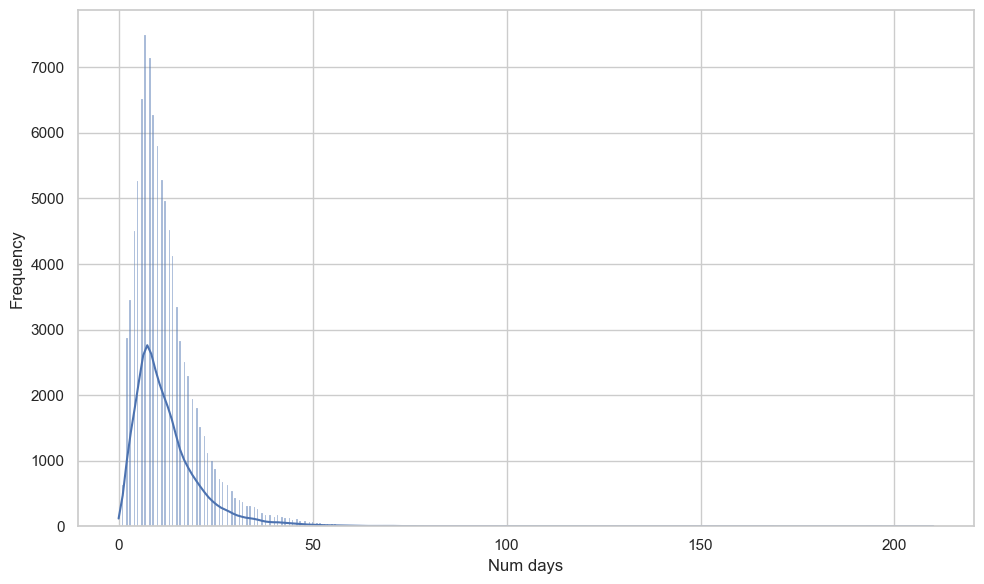

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [8]:
delivery_days_list = delivery_days.copy().tolist()

delivery_plot = Plotter()
delivery_plot.histogram(data=delivery_days_list, xlabel="Num days", ylabel="Frequency", show=True)

In [9]:
extream_delay = delivery_days[delivery_days > 100].copy()
high_delay = delivery_days[(delivery_days > 65) & (delivery_days < 100)].copy()

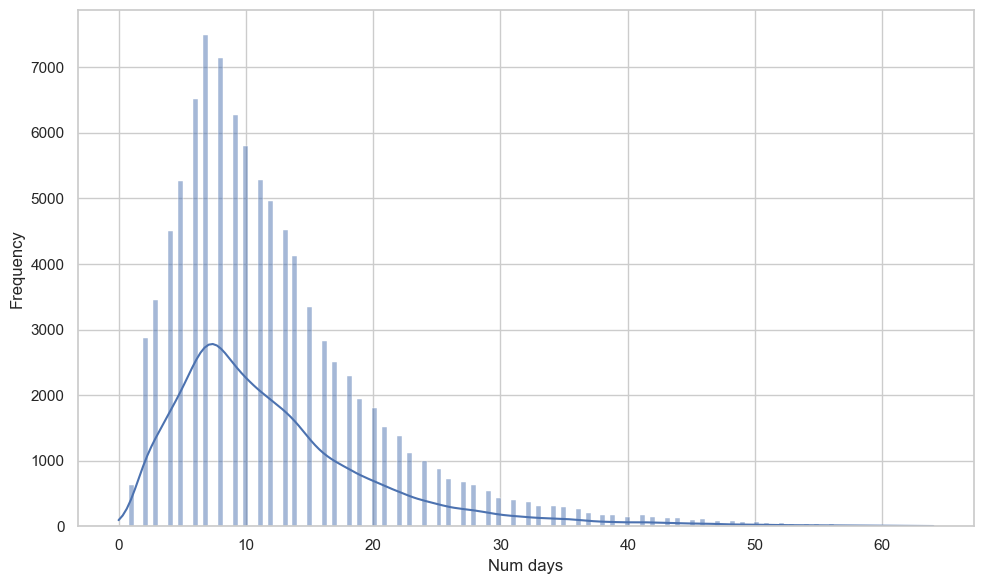

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [10]:
filtered_delivery_days_list = delivery_days[delivery_days < 65].copy().tolist()

delivery_plot.histogram(data=filtered_delivery_days_list, xlabel="Num days", ylabel="Frequency")

In [11]:
reviews = df.review_score.copy()

print(reviews.describe())

count     96127.0
mean     4.154691
std      1.285599
min           1.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: review_score, dtype: Float64


In [12]:
len(reviews[pd.isna(reviews)])

646

In [13]:
reviews = reviews.dropna()

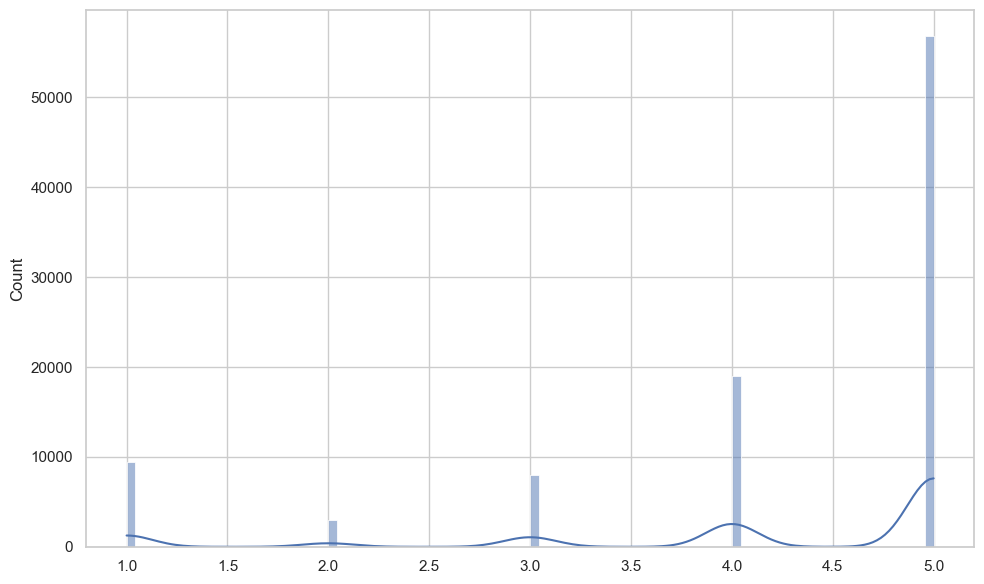

(<Figure size 1000x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [14]:
reviews_s_list = reviews.copy().tolist()

review_plot = Plotter()

review_plot.histogram(reviews_s_list)

In [15]:
feature_df = df.copy()

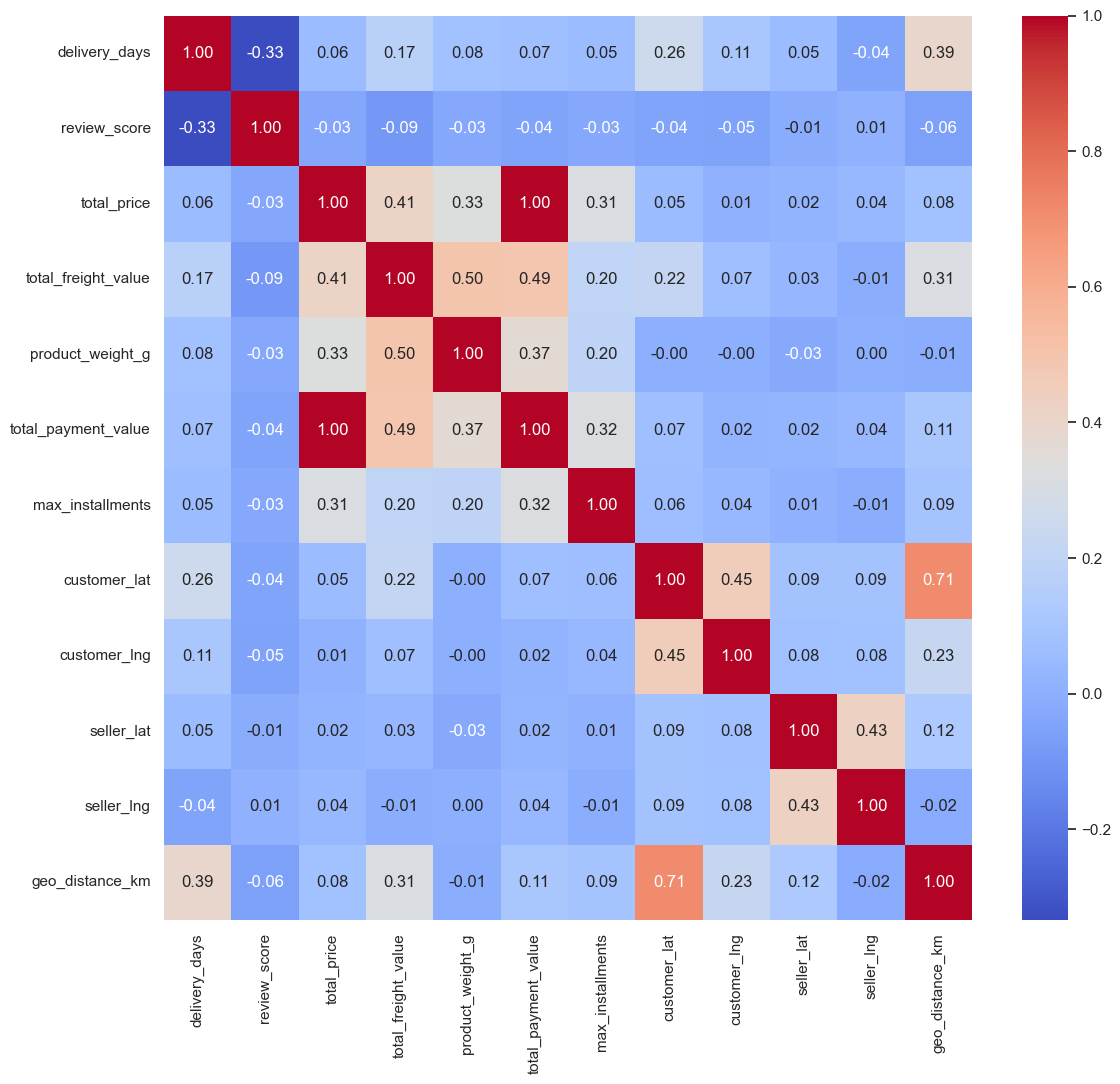

(<Figure size 1200x1100 with 2 Axes>, <Axes: >)

In [16]:
heatmap = Plotter()

heatmap.heatmap(data=feature_df)

In [17]:
deliveries_df = df.copy()[['order_purchase_timestamp', 'delivery_days']]

In [18]:
deliveries_df.head()

,order_purchase_timestamp,delivery_days
0,2017-07-20 18:57:41,6
1,2018-01-13 13:19:46,6
2,2017-08-03 19:48:22,22
3,2017-03-18 06:52:28,17
4,2017-01-10 17:18:09,16


In [19]:
deliveries_df.order_purchase_timestamp = pd.to_datetime(deliveries_df.order_purchase_timestamp)

In [20]:
deliveries_df['day_of_week'] = deliveries_df.order_purchase_timestamp.dt.day_name()
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week
0,2017-07-20 18:57:41,6,Thursday
1,2018-01-13 13:19:46,6,Saturday
2,2017-08-03 19:48:22,22,Thursday
3,2017-03-18 06:52:28,17,Saturday
4,2017-01-10 17:18:09,16,Tuesday


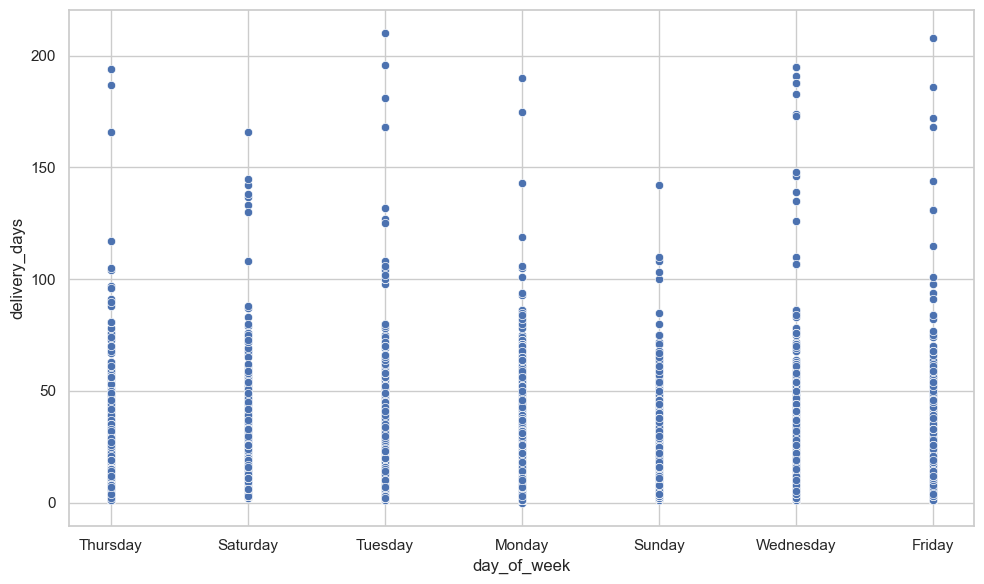

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='day_of_week', ylabel='delivery_days'>)

In [21]:
dow, dd = deliveries_df.copy()['day_of_week'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=dow, y=dd)

In [22]:
deliveries_df['hour_of_day'] = deliveries_df.order_purchase_timestamp.dt.hour
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week,hour_of_day
0,2017-07-20 18:57:41,6,Thursday,18
1,2018-01-13 13:19:46,6,Saturday,13
2,2017-08-03 19:48:22,22,Thursday,19
3,2017-03-18 06:52:28,17,Saturday,6
4,2017-01-10 17:18:09,16,Tuesday,17


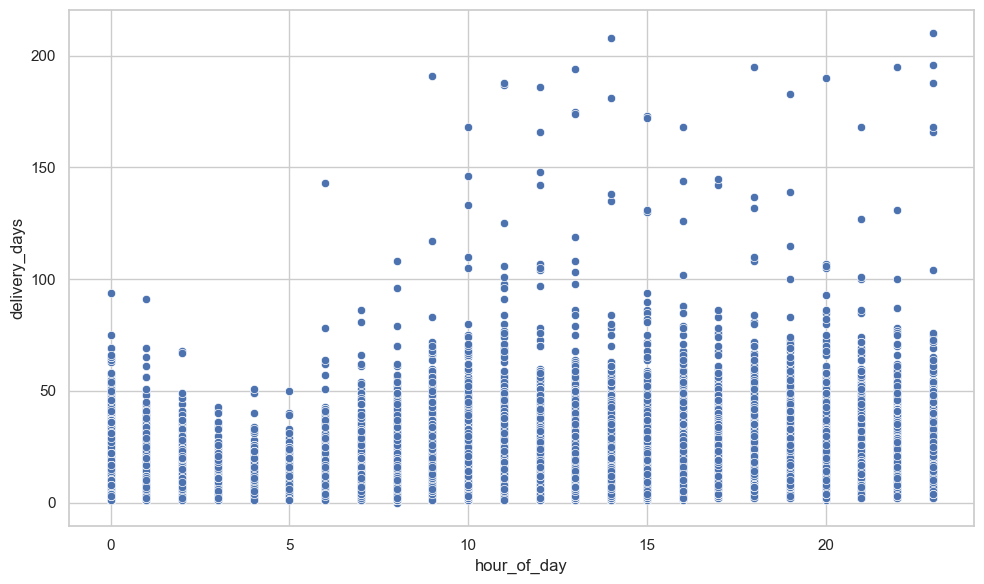

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='hour_of_day', ylabel='delivery_days'>)

In [23]:
hod, dd = deliveries_df.copy()['hour_of_day'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=hod, y=dd)

## Hypothesis Testing

### Mann-Whitney U Test

In [25]:
high_rated_deliveries = df[df['review_score'] >= 4]['delivery_days'].dropna().copy()
low_rated_deliveries = df[df['review_score'] <= 2]['delivery_days'].dropna().copy()

H0: There is no difference between the delivery days between high and low rated deliveries

In [68]:
U1, p = mannwhitneyu(high_rated_deliveries, low_rated_deliveries, alternative='greater')
print(U1, p)

287382086.0 1.0


In [69]:
U2 = len(high_rated_deliveries)*len(low_rated_deliveries) - U1
print(U2)

648356510.0


With the P value of 0, the null hypothises is rejected. This means that there is a difference between the delivery days for different review scores.

### Spearman Correlation between Distance and delivery days

H0: There is no correlation between delivery days and review score.

H1: There is a correlation between delivery days and review score.

In [47]:
distance = df.dropna(subset=['geo_distance_km', 'delivery_days'])['geo_distance_km'].copy()
deliveriy_days = df.dropna(subset=['geo_distance_km', 'delivery_days'])['delivery_days'].copy()

res = scipy.stats.spearmanr(distance, deliveriy_days)
res

SignificanceResult(statistic=np.float64(0.5406271630275318), pvalue=np.float64(0.0))

With a P value of 0, the null hypothesis is rejected. This means that there is a significant difference in the delivery times based on the distance between the seller and the customer.

### Kruskal-Wallis H-test

H0: Freight Value does not affect the review score

In [76]:
df_kw = df.dropna(subset=["review_score", "total_freight_value"]).copy()

df_kw['freight_quartile']  = pd.qcut(df_kw["total_freight_value"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

groups = [
    df_kw[df_kw["freight_quartile"] ==  q]["review_score"].values
    for q in ["Q1", "Q2", "Q3", "Q4"]
]

stat, p = scipy.stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={p:.2e}")

# Also print group medians to see the direction
print(df_kw.groupby('freight_quartile')['review_score'].median())


Kruskal-Wallis H=795.08, p=5.05e-172
freight_quartile
Q1    5.0
Q2    5.0
Q3    5.0
Q4    5.0
Name: review_score, dtype: Float64


In [77]:
print(df_kw.groupby('freight_quartile')['review_score'].mean().round(3))
print(df_kw.groupby('freight_quartile')['review_score'].value_counts(normalize=True).unstack())

freight_quartile
Q1    4.314
Q2     4.19
Q3    4.174
Q4     3.94
Name: review_score, dtype: Float64
review_score             1         2         3         4         5
freight_quartile                                                  
Q1                0.066065  0.025211  0.075051  0.195906  0.637767
Q2                0.089104  0.028758  0.084651  0.197977  0.599509
Q3                0.093125  0.028615  0.083143  0.201264  0.593853
Q4                0.142762  0.039802  0.087847  0.193472  0.536117


With a P value of 0, we reject the null hypothesis and accept the alternative hypothesis. This means that freight value affects review scores